In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from apyori import apriori

store_data = pd.read_csv(r"C:\Users\lucas.fandinoperez\Desktop\mes projets\a priori\data\store_data.csv", sep=",", header=None )
#store_data.head()
len(store_data)
store_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
 1   1       5747 non-null   object
 2   2       4389 non-null   object
 3   3       3345 non-null   object
 4   4       2529 non-null   object
 5   5       1864 non-null   object
 6   6       1369 non-null   object
 7   7       981 non-null    object
 8   8       654 non-null    object
 9   9       395 non-null    object
 10  10      256 non-null    object
 11  11      154 non-null    object
 12  12      87 non-null     object
 13  13      47 non-null     object
 14  14      25 non-null     object
 15  15      8 non-null      object
 16  16      4 non-null      object
 17  17      4 non-null      object
 18  18      3 non-null      object
 19  19      1 non-null      object
dtypes: object(20)
memory usage: 1.1+ MB


In [3]:
records = []
for i in range(0, 7501):
    records.append([str(store_data.values[i,j]) for j in range(0, 20)])

print(records[1])

['burgers', 'meatballs', 'eggs', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan']


In [4]:
association_rules = apriori(records, min_support=0.0045, min_confidence=0.2, min_lift=3, min_length=2)
association_results = list(association_rules)
len(association_results[0])



3

In [5]:
print(association_results[0])

RelationRecord(items=frozenset({'light cream', 'chicken'}), support=0.004532728969470737, ordered_statistics=[OrderedStatistic(items_base=frozenset({'light cream'}), items_add=frozenset({'chicken'}), confidence=0.29059829059829057, lift=4.84395061728395)])


In [6]:
for item in association_results:

    # first index of the inner list
    # Contains base item and add item
    pair = item[0] 
    items = [x for x in pair]
    print("Rule: " + items[0] + " -> " + items[1])

    #second index of the inner list
    print("Support: " + str(item[1]))

    #third index of the list located at 0th
    #of the third index of the inner list

    print("Confidence: " + str(item[2][0][2]))
    print("Lift: " + str(item[2][0][3]))
    print("=====================================")


Rule: light cream -> chicken
Support: 0.004532728969470737
Confidence: 0.29059829059829057
Lift: 4.84395061728395
Rule: mushroom cream sauce -> escalope
Support: 0.005732568990801226
Confidence: 0.3006993006993007
Lift: 3.790832696715049
Rule: pasta -> escalope
Support: 0.005865884548726837
Confidence: 0.3728813559322034
Lift: 4.700811850163794
Rule: herb & pepper -> ground beef
Support: 0.015997866951073192
Confidence: 0.3234501347708895
Lift: 3.2919938411349285
Rule: tomato sauce -> ground beef
Support: 0.005332622317024397
Confidence: 0.3773584905660377
Lift: 3.840659481324083
Rule: whole wheat pasta -> olive oil
Support: 0.007998933475536596
Confidence: 0.2714932126696833
Lift: 4.122410097642296
Rule: shrimp -> pasta
Support: 0.005065991201173177
Confidence: 0.3220338983050847
Lift: 4.506672147735896
Rule: nan -> light cream
Support: 0.004532728969470737
Confidence: 0.29059829059829057
Lift: 4.84395061728395
Rule: shrimp -> chocolate
Support: 0.005332622317024397
Confidence: 0.2325

*** WORKSHOP 2 ***

In [7]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules


######## EXAMPLE 1 

data = {'ID':[1,2,3,4,5,6],
       'Onion':[1,0,0,1,1,1],
       'Potato':[1,1,0,1,1,1],
       'Burger':[1,1,0,0,1,1],
       'Milk':[0,1,1,1,0,1],
       'Beer':[0,0,1,0,1,0]}

df = pd.DataFrame(data)

df = df[['ID', 'Onion', 'Potato', 'Burger', 'Milk', 'Beer' ]]

frequent_itemsets = apriori(df[['Onion', 'Potato', 'Burger', 'Milk', 'Beer' ]], min_support=0.50, use_colnames=True)
print(frequent_itemsets)

    support                 itemsets
0  0.666667                  (Onion)
1  0.833333                 (Potato)
2  0.666667                 (Burger)
3  0.666667                   (Milk)
4  0.666667          (Potato, Onion)
5  0.500000          (Burger, Onion)
6  0.666667         (Potato, Burger)
7  0.500000           (Potato, Milk)
8  0.500000  (Potato, Burger, Onion)


c:\Users\lucas.fandinoperez\AppData\Local\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [8]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)
print(rules)

         antecedents       consequents  antecedent support  \
0           (Potato)           (Onion)            0.833333   
1            (Onion)          (Potato)            0.666667   
2           (Burger)           (Onion)            0.666667   
3            (Onion)          (Burger)            0.666667   
4           (Potato)          (Burger)            0.833333   
5           (Burger)          (Potato)            0.666667   
6   (Potato, Burger)           (Onion)            0.666667   
7    (Potato, Onion)          (Burger)            0.666667   
8    (Burger, Onion)          (Potato)            0.500000   
9           (Potato)   (Burger, Onion)            0.833333   
10          (Burger)   (Potato, Onion)            0.666667   
11           (Onion)  (Potato, Burger)            0.666667   

    consequent support   support  confidence   lift  representativity  \
0             0.666667  0.666667        0.80  1.200               1.0   
1             0.833333  0.666667        1.00  1

In [9]:
##### When we subset lift and confidence values

rules [ (rules['lift'] >1.125)  & (rules['confidence']> 0.8)  ]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,(Onion),(Potato),0.666667,0.833333,0.666667,1.0,1.2,1.0,0.111111,inf,0.500000,0.8,1.0,0.9
5,(Burger),(Potato),0.666667,0.833333,0.666667,1.0,1.2,1.0,0.111111,inf,0.500000,0.8,1.0,0.9
8,"(Burger, Onion)",(Potato),0.500000,0.833333,0.500000,1.0,1.2,1.0,0.083333,inf,0.333333,0.6,1.0,0.8


In [10]:
################ EXAMPLE 2 ########################

retail_shopping_basket = {'ID':[1,2,3,4,5,6],
                         'Basket':[['Beer', 'Diaper', 'Pretzels', 'Chips', 'Aspirin'],
                                   ['Diaper', 'Beer', 'Chips', 'Lotion', 'Juice', 'BabyFood', 'Milk'],
                                   ['Soda', 'Chips', 'Milk'],
                                   ['Soup', 'Beer', 'Diaper', 'Milk', 'IceCream'],
                                   ['Soda', 'Coffee', 'Milk', 'Bread'],
                                   ['Beer', 'Chips']
                                  ]
                         }

retail = pd.DataFrame(retail_shopping_basket)

retail = retail[['ID', 'Basket']]
pd.options.display.max_colwidth=100


retail = retail.drop('Basket', axis = 1).join(retail.Basket.str.join(',').str.get_dummies(','))
#print(retail)


frequent_itemsets_2 = apriori(retail.drop('ID',axis = 1), use_colnames=True)
frequent_itemsets_2



c:\Users\lucas.fandinoperez\AppData\Local\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.666667,(Beer)
1,0.666667,(Chips)
2,0.500000,(Diaper)
3,0.666667,(Milk)
4,0.500000,"(Beer, Chips)"
5,0.500000,"(Beer, Diaper)"


In [11]:
association_rules(frequent_itemsets_2, metric='lift')
#association_rules(frequent_itemsets_2)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Beer),(Chips),0.666667,0.666667,0.5,0.75,1.125,1.0,0.055556,1.333333,0.333333,0.60,0.25,0.750
1,(Chips),(Beer),0.666667,0.666667,0.5,0.75,1.125,1.0,0.055556,1.333333,0.333333,0.60,0.25,0.750
2,(Beer),(Diaper),0.666667,0.500000,0.5,0.75,1.500,1.0,0.166667,2.000000,1.000000,0.75,0.50,0.875
3,(Diaper),(Beer),0.500000,0.666667,0.5,1.00,1.500,1.0,0.166667,inf,0.666667,0.75,1.00,0.875


In [12]:
############## EXAMPLE 3 ################
movies = pd.read_csv(r"C:\Users\lucas.fandinoperez\Desktop\mes projets\a priori\data\movies.csv", sep= ",")
movies.head(10)
movies_ohe = movies.drop('genres',axis = 1).join(movies.genres.str.get_dummies())
pd.options.display.max_columns=100
movies_ohe.head()




,movieId,title,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
stat1 = movies_ohe.drop(['title', 'movieId'],axis = 1).apply(pd.value_counts)

stat1 = stat1.transpose().drop(0,axis = 1).sort_values(by=1, ascending=False).rename(columns={1:'No. of movies'})

stat1

C:\Users\lucas.fandinoperez\AppData\Local\Temp\ipykernel_19112\1963353341.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  stat1 = movies_ohe.drop(['title', 'movieId'],axis = 1).apply(pd.value_counts)


,No. of movies
Drama,4361
Comedy,3756
Thriller,1894
Action,1828
Romance,1596
Adventure,1263
Crime,1199
Sci-Fi,980
Horror,978
Fantasy,779


In [14]:
stat2 = movies.join(movies.genres.str.split('|').reset_index().genres.str.len(), rsuffix='r').rename(columns={'genresr':'genre_count'})
stat2 = stat2[stat2['genre_count']==1].drop(['movieId','title'],axis = 1).groupby('genres').sum().sort_values(by='genre_count', ascending=False)
stat2


,genre_count
genres,
Drama,1053
Comedy,946
Documentary,339
Horror,167
Thriller,84
Action,60
Sci-Fi,37
(no genres listed),34
Animation,30


In [15]:

stat = stat1.merge(stat2, how='left', left_index=True, right_index=True).fillna(0)
stat.genre_count=stat.genre_count.astype(int)
stat.rename(columns={'genre_count': 'No. of movies with only 1 genre'},inplace=True)
stat

,No. of movies,No. of movies with only 1 genre
Drama,4361,1053
Comedy,3756,946
Thriller,1894,84
Action,1828,60
Romance,1596,21
Adventure,1263,12
Crime,1199,12
Sci-Fi,980,37
Horror,978,167
Fantasy,779,4


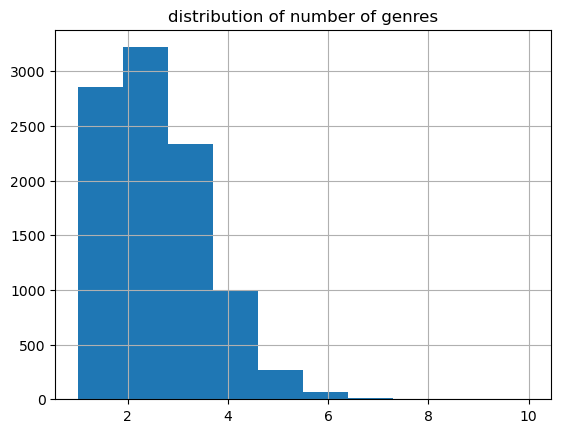

c:\Users\lucas.fandinoperez\AppData\Local\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.187641,(Action)
1,0.129645,(Adventure)
2,0.062718,(Animation)
3,0.068158,(Children)
4,0.385547,(Comedy)
5,0.123075,(Crime)
6,0.045165,(Documentary)
7,0.447649,(Drama)
8,0.079963,(Fantasy)
9,0.100390,(Horror)


In [16]:
############## EXAMPLE 3 ################
movies = pd.read_csv(r"C:\Users\lucas.fandinoperez\Desktop\mes projets\a priori\data\movies.csv", sep= ",")
movies_ohe = movies.drop('genres',axis = 1).join(movies.genres.str.get_dummies())

import matplotlib.pyplot as plt
%matplotlib inline
movies_ohe.set_index(['movieId','title']).sum(axis=1).hist()
plt.title('distribution of number of genres')
plt.show()

movies_ohe.set_index(['movieId','title'],inplace=True)
frequent_itemsets_movies = apriori(movies_ohe,use_colnames=True, min_support=0.025)
frequent_itemsets_movies

In [17]:
rules_movies =  association_rules(frequent_itemsets_movies, metric='lift', min_threshold=1.25)
rules_movies

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Adventure),(Action),0.129645,0.187641,0.062615,0.482977,2.573940,1.0,0.038289,1.571224,0.702576,0.245869,0.363553,0.408338
1,(Action),(Adventure),0.187641,0.129645,0.062615,0.333698,2.573940,1.0,0.038289,1.306247,0.752735,0.245869,0.234448,0.408338
2,(Crime),(Action),0.123075,0.187641,0.042907,0.348624,1.857929,1.0,0.019813,1.247142,0.526575,0.160215,0.198167,0.288645
3,(Action),(Crime),0.187641,0.123075,0.042907,0.228665,1.857929,1.0,0.019813,1.136892,0.568426,0.160215,0.120409,0.288645
4,(Action),(Sci-Fi),0.187641,0.100595,0.046294,0.246718,2.452576,1.0,0.027419,1.193981,0.729069,0.191345,0.162466,0.353461
5,(Sci-Fi),(Action),0.100595,0.187641,0.046294,0.460204,2.452576,1.0,0.027419,1.504937,0.658508,0.191345,0.335520,0.353461
6,(Thriller),(Action),0.194416,0.187641,0.067235,0.345829,1.843034,1.0,0.030754,1.241814,0.567807,0.213564,0.194726,0.352072
7,(Action),(Thriller),0.187641,0.194416,0.067235,0.358315,1.843034,1.0,0.030754,1.255420,0.563072,0.213564,0.203454,0.352072
8,(Animation),(Adventure),0.062718,0.129645,0.025354,0.404255,3.118175,1.0,0.017223,1.460953,0.724755,0.151813,0.315515,0.299911
9,(Adventure),(Animation),0.129645,0.062718,0.025354,0.195566,3.118175,1.0,0.017223,1.165145,0.780486,0.151813,0.141737,0.299911


In [18]:
rules_movies[(rules_movies.conviction>1.25)]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Adventure),(Action),0.129645,0.187641,0.062615,0.482977,2.573940,1.0,0.038289,1.571224,0.702576,0.245869,0.363553,0.408338
1,(Action),(Adventure),0.187641,0.129645,0.062615,0.333698,2.573940,1.0,0.038289,1.306247,0.752735,0.245869,0.234448,0.408338
5,(Sci-Fi),(Action),0.100595,0.187641,0.046294,0.460204,2.452576,1.0,0.027419,1.504937,0.658508,0.191345,0.335520,0.353461
7,(Action),(Thriller),0.187641,0.194416,0.067235,0.358315,1.843034,1.0,0.030754,1.255420,0.563072,0.213564,0.203454,0.352072
8,(Animation),(Adventure),0.062718,0.129645,0.025354,0.404255,3.118175,1.0,0.017223,1.460953,0.724755,0.151813,0.315515,0.299911
10,(Children),(Adventure),0.068158,0.129645,0.032026,0.469880,3.624360,1.0,0.023190,1.641806,0.777052,0.193189,0.390915,0.358455
12,(Fantasy),(Adventure),0.079963,0.129645,0.034285,0.428755,3.307149,1.0,0.023918,1.523610,0.758257,0.195550,0.343664,0.346602
13,(Adventure),(Fantasy),0.129645,0.079963,0.034285,0.264450,3.307149,1.0,0.023918,1.250815,0.801540,0.195550,0.200521,0.346602
15,(Sci-Fi),(Adventure),0.100595,0.129645,0.031410,0.312245,2.408464,1.0,0.018369,1.265502,0.650205,0.157976,0.209799,0.277263
16,(Animation),(Children),0.062718,0.068158,0.031000,0.494272,7.251799,1.0,0.026725,1.842573,0.919791,0.310380,0.457281,0.474545


In [19]:
rules_movies[(rules_movies.conviction>1.5)].sort_values(by=['lift','conviction'], ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
16,(Animation),(Children),0.062718,0.068158,0.031000,0.494272,7.251799,1.0,0.026725,1.842573,0.919791,0.310380,0.457281,0.474545
17,(Children),(Animation),0.068158,0.062718,0.031000,0.454819,7.251799,1.0,0.026725,1.719213,0.925161,0.310380,0.418339,0.474545
10,(Children),(Adventure),0.068158,0.129645,0.032026,0.469880,3.624360,1.0,0.023190,1.641806,0.777052,0.193189,0.390915,0.358455
12,(Fantasy),(Adventure),0.079963,0.129645,0.034285,0.428755,3.307149,1.0,0.023918,1.523610,0.758257,0.195550,0.343664,0.346602
31,(Mystery),(Thriller),0.058817,0.194416,0.036338,0.617801,3.177729,1.0,0.024902,2.107761,0.728137,0.167534,0.525563,0.402354
0,(Adventure),(Action),0.129645,0.187641,0.062615,0.482977,2.573940,1.0,0.038289,1.571224,0.702576,0.245869,0.363553,0.408338
36,"(Drama, Crime)",(Thriller),0.065387,0.194416,0.031718,0.485086,2.495096,1.0,0.019006,1.564503,0.641136,0.139064,0.360819,0.324117
5,(Sci-Fi),(Action),0.100595,0.187641,0.046294,0.460204,2.452576,1.0,0.027419,1.504937,0.658508,0.191345,0.335520,0.353461
22,(Crime),(Thriller),0.123075,0.194416,0.058407,0.474562,2.440963,1.0,0.034479,1.533167,0.673177,0.225436,0.347755,0.387492
28,(Horror),(Thriller),0.100390,0.194416,0.047116,0.469325,2.414026,1.0,0.027598,1.518037,0.651120,0.190220,0.341255,0.355835


In [20]:
pd.options.display.max_rows=50

movies[(movies.genres.str.contains('Adventure')) & (movies.genres.str.contains('Children')) & (~movies.genres.str.contains('Animation'))]

,movieId,title,genres
1,2,Jumanji (1995),Adventure|Children|Fantasy
7,8,Tom and Huck (1995),Adventure|Children
53,60,"Indian in the Cupboard, The (1995)",Adventure|Children|Fantasy
95,107,Muppet Treasure Island (1996),Adventure|Children|Comedy|Musical
109,126,"NeverEnding Story III, The (1994)",Adventure|Children|Fantasy
...,...,...,...
9428,166203,Sapphire Blue (2014),Adventure|Children|Fantasy|Sci-Fi
9565,173873,Gulliver's Travels (1996),Adventure|Children|Fantasy
9636,179401,Jumanji: Welcome to the Jungle (2017),Action|Adventure|Children
9697,184987,A Wrinkle in Time (2018),Adventure|Children|Fantasy|Sci-Fi


*** WORKSHOP 3 ***

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
sns.set(style="darkgrid", color_codes=True)
pd.set_option('display.max_columns', 75)

In [22]:
data = pd.read_csv(r"C:\Users\lucas.fandinoperez\Desktop\mes projets\a priori\data\Market_Basket_Optimisation.csv", header = None)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
 1   1       5747 non-null   object
 2   2       4389 non-null   object
 3   3       3345 non-null   object
 4   4       2529 non-null   object
 5   5       1864 non-null   object
 6   6       1369 non-null   object
 7   7       981 non-null    object
 8   8       654 non-null    object
 9   9       395 non-null    object
 10  10      256 non-null    object
 11  11      154 non-null    object
 12  12      87 non-null     object
 13  13      47 non-null     object
 14  14      25 non-null     object
 15  15      8 non-null      object
 16  16      4 non-null      object
 17  17      4 non-null      object
 18  18      3 non-null      object
 19  19      1 non-null      object
dtypes: object(20)
memory usage: 1.1+ MB


In [23]:
data.head()
data.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,7501,5747,4389,3345,2529,1864,1369,981,654,395,256,154,87,47,25,8,4,4,3,1
unique,115,117,115,114,110,106,102,98,88,80,66,50,43,28,19,8,3,3,3,1
top,mineral water,mineral water,mineral water,mineral water,green tea,french fries,green tea,green tea,green tea,green tea,low fat yogurt,green tea,green tea,green tea,magazines,salmon,frozen smoothie,protein bar,spinach,olive oil
freq,577,484,375,201,153,107,96,67,57,31,22,15,8,4,3,1,2,2,1,1


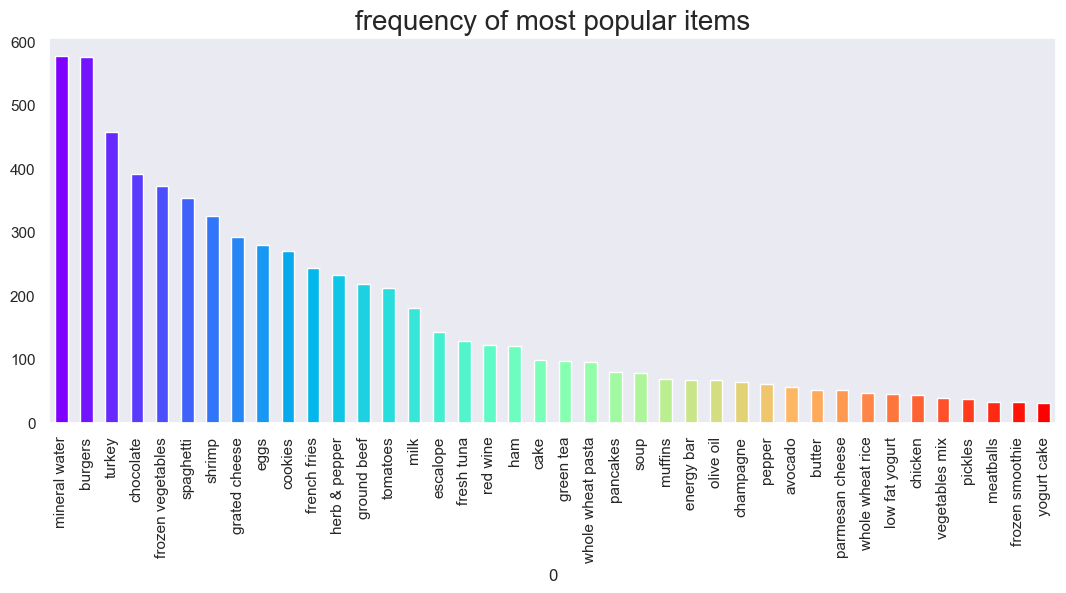

In [24]:
color = plt.cm.rainbow(np.linspace(0, 1, 40))
data[0].value_counts().head(40).plot.bar(color = color, figsize=(13,5))
plt.title('frequency of most popular items', fontsize = 20)
plt.xticks(rotation = 90 )
plt.grid()
plt.show()

In [25]:
import networkx as nx
data['food'] = 'Food'
food = data.truncate(before = -1, after = 15)
food = nx.from_pandas_edgelist(food, source = 'food', target = 0, edge_attr = True)
food

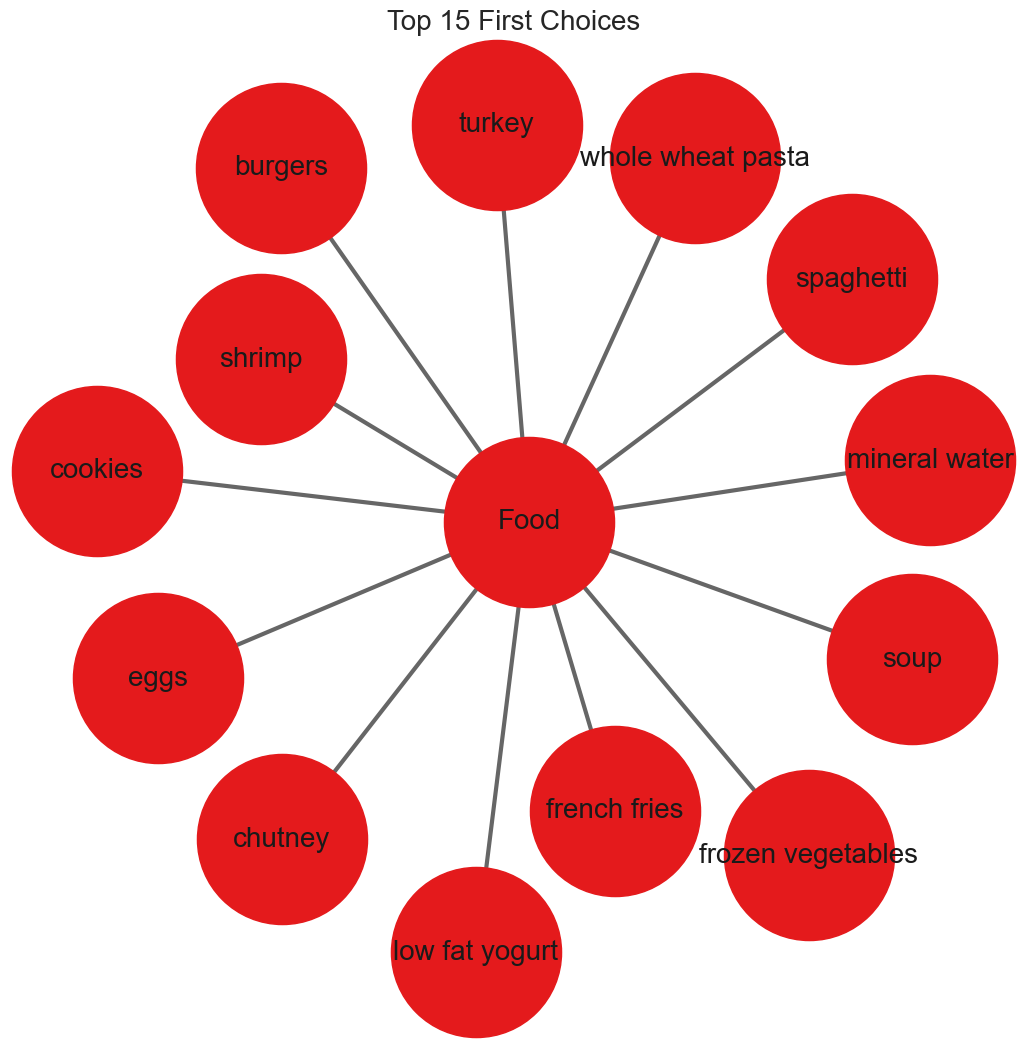

In [26]:
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 13)
pos = nx.spring_layout(food)
color = plt.cm.Set1(np.linspace(0, 15, 1))
nx.draw_networkx_nodes(food, pos, node_size = 15000, node_color = color)
nx.draw_networkx_edges(food, pos, width = 3, alpha = 0.6, edge_color = 'black')
nx.draw_networkx_labels(food, pos, font_size = 20, font_family = 'sans-serif')
plt.axis('off')
plt.grid()
plt.title('Top 15 First Choices', fontsize = 20)
plt.show()

In [ ]:
####Getting the list of transactions for the dataset
import pandas as pd

transactions = []

for i in range(0, len(data)):
    transactions.append([str(data.values[i,j]) for j in range(0, len(data.columns))])

transactions[:1]

In [ ]:
from itertools import permutations

# Extract unique items.
flattened = [item for transaction in transactions for item in transaction]
items = list(set(flattened))

print('# of items:',len(items))
print(list(items))

# of items: 121
['pancakes', 'gums', 'eggs', 'dessert wine', 'light mayo', 'cottage cheese', 'brownies', 'shampoo', 'strong cheese', 'mashed potato', 'melons', 'oil', 'fresh tuna', 'black tea', 'flax seed', 'carrots', 'butter', 'tomato juice', 'chocolate bread', 'babies food', 'salmon', 'body spray', 'magazines', 'salt', 'zucchini', 'low fat yogurt', 'napkins', 'whole weat flour', 'pasta', 'nan', 'french fries', 'cereals', 'mayonnaise', 'parmesan cheese', 'cake', 'green grapes', 'cider', 'candy bars', 'hand protein bar', 'green beans', 'rice', 'burgers', 'green tea', 'french wine', 'ground beef', 'salad', 'tomato sauce', 'cookies', 'champagne', 'antioxydant juice', 'bacon', 'escalope', 'burger sauce', 'frozen smoothie', 'shrimp', 'cooking oil', 'corn', 'soda', 'energy drink', 'mint green tea', 'mint', 'sandwich', 'pet food', 'vegetables mix', 'strawberries', 'ketchup', 'meatballs', 'turkey', 'asparagus', 'yams', 'pepper', 'yogurt cake', 'chocolate', 'fromage blanc', 'cauliflower', 'hon

In [ ]:
if 'nan' in items: items.remove('nan')
print(list(items))

['pancakes', 'gums', 'eggs', 'dessert wine', 'light mayo', 'cottage cheese', 'brownies', 'shampoo', 'strong cheese', 'mashed potato', 'melons', 'oil', 'fresh tuna', 'black tea', 'flax seed', 'carrots', 'butter', 'tomato juice', 'chocolate bread', 'babies food', 'salmon', 'body spray', 'magazines', 'salt', 'zucchini', 'low fat yogurt', 'napkins', 'whole weat flour', 'pasta', 'french fries', 'cereals', 'mayonnaise', 'parmesan cheese', 'cake', 'green grapes', 'cider', 'candy bars', 'hand protein bar', 'green beans', 'rice', 'burgers', 'green tea', 'french wine', 'ground beef', 'salad', 'tomato sauce', 'cookies', 'champagne', 'antioxydant juice', 'bacon', 'escalope', 'burger sauce', 'frozen smoothie', 'shrimp', 'cooking oil', 'corn', 'soda', 'energy drink', 'mint green tea', 'mint', 'sandwich', 'pet food', 'vegetables mix', 'strawberries', 'ketchup', 'meatballs', 'turkey', 'asparagus', 'yams', 'pepper', 'yogurt cake', 'chocolate', 'fromage blanc', 'cauliflower', 'honey', 'soup', 'chicken',

In [ ]:
# Compute and print rules.
rules = list(permutations(items, 2))
print('# of rules:',len(rules))
print(rules[:5])

# of rules: 14280
[('pancakes', 'gums'), ('pancakes', 'eggs'), ('pancakes', 'dessert wine'), ('pancakes', 'light mayo'), ('pancakes', 'cottage cheese')]


In [ ]:
# Import the transaction encoder function from mlxtend
from mlxtend.preprocessing import TransactionEncoder

# Instantiate transaction encoder and identify unique items
encoder = TransactionEncoder().fit(transactions)

# One-hot encode transactions
onehot = encoder.transform(transactions)

# Convert one-hot encoded data to DataFrame
onehot = pd.DataFrame(onehot, columns = encoder.columns_).drop('nan', axis=1)

# Print the one-hot encoded transaction dataset
onehot.head()

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,bramble,brownies,bug spray,burger sauce,burgers,butter,cake,candy bars,carrots,cauliflower,cereals,champagne,chicken,chili,chocolate,chocolate bread,chutney,cider,clothes accessories,cookies,cooking oil,corn,cottage cheese,cream,dessert wine,eggplant,...,parmesan cheese,pasta,pepper,pet food,pickles,protein bar,red wine,rice,salad,salmon,salt,sandwich,shallot,shampoo,shrimp,soda,soup,spaghetti,sparkling water,spinach,strawberries,strong cheese,tea,tomato juice,tomato sauce,tomatoes,toothpaste,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


***METRICS AND PRUNING ***

In [ ]:
# Compute the support
support = onehot.mean()
support = pd.DataFrame(support, columns=['support']).sort_values('support',ascending=False)

# Print the support
support.head(10)

support.describe()

,support
count,120.000000
mean,0.032616
std,0.042370
min,0.000133
25%,0.007566
50%,0.015665
75%,0.035929
max,0.238368


***CONFIDENCE AND LIFT ***

In [ ]:
# Compute support for burgers and french fries
supportBF = np.logical_and(onehot['burgers'], onehot['french fries']).mean()

# Compute support for burgers and mineral water
supportBM = np.logical_and(onehot['burgers'], onehot['mineral water']).mean()

# Compute support for french fries and mineral water
supportFM = np.logical_and(onehot['french fries'], onehot['mineral water']).mean()

# Print support values
print("burgers and french fries: %.2f" % supportBF)
print("burgers and mineral water: %.2f" % supportBM)
print("french fries and mineral water: %.2f" % supportFM)

burgers and french fries: 0.02
burgers and mineral water: 0.02
french fries and mineral water: 0.03


In [ ]:
# Add a mineral water+french fries column to the DataFrame onehot
onehot['mineral water+french fries'] = np.logical_and(onehot['mineral water'], onehot['french fries'])

# Compute the support
support = onehot.mean()
val = support.loc['mineral water+french fries']

# Print the support values
print(f'mineral water+french fries support = {val}')

mineral water+french fries support = 0.03372883615517931


In [ ]:
# Compute support for mineral water and french fries
supportMF = np.logical_and(onehot['mineral water'], onehot['french fries']).mean()

# Compute support for mineral water
supportM = onehot['mineral water'].mean()

# Compute support for french fries
supportF = onehot['french fries'].mean()

# Compute confidence for both rules
confidenceMM = supportMF / supportM
confidenceMF = supportMF / supportF

# Print results
print('mineral water = {0:.2f}, french fries = {1:.2f}'.format(confidenceMM, confidenceMF))

mineral water = 0.14, french fries = 0.20


In [ ]:
# Compute lift
lift = supportMF / (supportM * supportF)

# Print lift
print("Lift: %.2f" % lift)

Lift: 0.83


*** LEVERAGE AND CONVICTION ***

In [ ]:
# Compute support for burgers AND french fries
supportBF = np.logical_and(onehot['burgers'], onehot['french fries']).mean()

# Compute support for burgers
supportB = onehot['burgers'].mean()

# Compute support for NOT french fries
supportnF = 1.0 - onehot['french fries'].mean()

# Compute support for burgers and NOT french fries
supportBnF = supportB - supportBF

# Compute and print conviction for burgers -> french fries
conviction = supportB * supportnF / supportBnF
print("Conviction: %.2f" % conviction)

Conviction: 1.11


In [ ]:
##### définition des fonctions

def conviction(antecedent, consequent):
    # Compute support for antecedent AND consequent
    supportAC = np.logical_and(antecedent, consequent).mean()

    # Compute support for antecedent
    supportA = antecedent.mean()

    # Compute support for NOT consequent
    supportnC = 1.0 - consequent.mean()

    # Compute support for antecedent and NOT consequent
    supportAnC = supportA - supportAC

    # Return conviction
    return supportA * supportnC / supportAnC

def leverage(antecedent, consequent):
    # Compute support for antecedent AND consequent
    supportAB = np.logical_and(antecedent, consequent).mean()

    # Compute support for antecedent
    supportA = antecedent.mean()

    # Compute support for consequent
    supportB = consequent.mean()

    # Return leverage
    return supportAB - supportB * supportA

#### appel des fonctions

# Compute conviction for burgers -> french fries and french fries -> burgers
convictionBF = conviction(onehot['burgers'], onehot['french fries'])
convictionFB = conviction(onehot['french fries'], onehot['burgers'])

# Compute conviction for burgers -> mineral water and mineral water -> burgers
convictionBM = conviction(onehot['burgers'], onehot['mineral water'])
convictionMB = conviction(onehot['mineral water'], onehot['burgers'])

# Compute conviction for french fries -> mineral water and mineral water -> french fries
convictionFM = conviction(onehot['french fries'], onehot['mineral water'])
convictionMF = conviction(onehot['mineral water'], onehot['french fries'])

# Print results
print('french fries -> burgers: ', convictionFB)
print('burgers -> french fries: ', convictionBF)



french fries -> burgers:  1.0476495106531305
burgers -> french fries:  1.1088435652342468


*** ASSOCIATION AND DISSOCIATION ***

In [ ]:
####### Zhang's metric

# Compute the support of burgers and french fries
supportT = onehot['burgers'].mean()
supportP = onehot['french fries'].mean()

# Compute the support of both food items
supportTP = np.logical_and(onehot['burgers'], onehot['french fries']).mean()

# Complete the expressions for the numerator and denominator
numerator = supportTP - supportT*supportP
denominator = max(supportTP*(1-supportT), supportT*(supportP-supportTP))

# Compute and print Zhang's metric
zhang = numerator / denominator
print(zhang)

0.3533836982354581


In [ ]:
############## Zhang function defined

def zhang(antecedent, consequent):
    # Compute the support of each book
    supportA = antecedent.mean()
    supportC = consequent.mean()

    # Compute the support of both books
    supportAC = np.logical_and(antecedent, consequent).mean()

    # Complete the expressions for the numerator and denominator
    numerator = supportAC - supportA*supportC
    denominator = max(supportAC*(1-supportA), supportA*(supportC-supportAC))

    # Return Zhang's metric
    return numerator / denominator

####### Applying Zhang func

# Create rules DataFrame
rules_ = pd.DataFrame(rules, columns=['antecedents','consequents'])

# Define an empty list for metrics
zhangs, conv, lev, antec_supp, cons_supp, suppt, conf, lft = [], [], [], [], [], [], [], []

# Loop over lists in itemsets
for itemset in rules:
    # Extract the antecedent and consequent columns
    antecedent = onehot[itemset[0]]
    consequent = onehot[itemset[1]]
    
    antecedent_support = onehot[itemset[0]].mean()
    consequent_support = onehot[itemset[1]].mean()
    support = np.logical_and(onehot[itemset[0]], onehot[itemset[1]]).mean()
    confidence = support / antecedent_support
    lift = support / (antecedent_support * consequent_support)
    
    # Complete metrics and append it to the list
    antec_supp.append(antecedent_support)
    cons_supp.append(consequent_support)
    suppt.append(support)
    conf.append(confidence)
    lft.append(lift)
    lev.append(leverage(antecedent, consequent))
    conv.append(conviction(antecedent, consequent))
    zhangs.append(zhang(antecedent, consequent))
    
# Store results
rules_['antecedent support'] = antec_supp
rules_['consequent support'] = cons_supp
rules_['support'] = suppt
rules_['confidence'] = conf
rules_['lift'] = lft
rules_['leverage'] = lev
rules_['conviction'] = conv
rules_['zhang'] = zhangs

# Print results
rules_.sort_values('zhang',ascending=False).head(10)
rules_.describe()


,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhang
count,14280.000000,14280.000000,14280.000000,14280.000000,14280.000000,14280.000000,1.428000e+04,14280.000000
mean,0.032616,0.032616,0.001389,0.044870,1.475580,0.000341,inf,-0.011826
std,0.042195,0.042195,0.003351,0.066355,1.879564,0.001157,NaN,0.623612
min,0.000133,0.000133,0.000000,0.000000,0.000000,-0.011697,7.616318e-01,-1.000000
25%,0.007566,0.007566,0.000133,0.004902,0.475787,-0.000048,9.953340e-01,-0.534745
50%,0.015665,0.015665,0.000400,0.021739,1.236564,0.000085,1.004127e+00,0.199959
75%,0.035929,0.035929,0.001200,0.056872,1.874834,0.000370,1.021102e+00,0.485044
max,0.238368,0.238368,0.059725,1.000000,45.460606,0.022088,inf,1.000000


In [ ]:
rules_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14280 entries, 0 to 14279
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   antecedents         14280 non-null  object 
 1   consequents         14280 non-null  object 
 2   antecedent support  14280 non-null  float64
 3   consequent support  14280 non-null  float64
 4   support             14280 non-null  float64
 5   confidence          14280 non-null  float64
 6   lift                14280 non-null  float64
 7   leverage            14280 non-null  float64
 8   conviction          14280 non-null  float64
 9   zhang               14280 non-null  float64
dtypes: float64(8), object(2)
memory usage: 1.1+ MB


***OVERVIEW OF MARKET BASKET ANALYSIS ***

In [ ]:
###Filtering with support and conviction

# Select the subset of rules with antecedent support greater than 0.05
rules_filtered = rules_[rules_['antecedent support'] > 0.05]

# Select the subset of rules with a consequent support greater than 0.01
rules_filtered = rules_[rules_['consequent support'] > 0.01]

# Select the subset of rules with a conviction greater than 1.01
rules_filtered = rules_[rules_['conviction'] > 1.01]

# Select the subset of rules with a lift greater than 1.0
rules_filtered = rules_[rules_['lift'] > 1.0]

# Print remaining rules
print(f'# of rules = {len(rules_)}')
print(f'# of rules after filtering = {len(rules_filtered)}')
print(rules_filtered.head())


# of rules = 14280
# of rules after filtering = 8598
  antecedents     consequents  antecedent support  consequent support  \
0    pancakes            gums            0.095054            0.013465   
1    pancakes            eggs            0.095054            0.179709   
2    pancakes    dessert wine            0.095054            0.004399   
3    pancakes      light mayo            0.095054            0.027196   
4    pancakes  cottage cheese            0.095054            0.031862   

    support  confidence      lift  leverage  conviction     zhang  
0  0.001866    0.019635  1.458264  0.000587    1.006294  0.347262  
1  0.021730    0.228612  1.272118  0.004648    1.063395  0.236378  
2  0.000533    0.005610  1.275192  0.000115    1.001218  0.238472  
3  0.005466    0.057504  2.114381  0.002881    1.032156  0.582409  
4  0.005199    0.054698  1.716708  0.002171    1.024157  0.461342  


In [ ]:
##### using multi-metrics

# Set the threshold for Zhang's rule to 0.65
rules_filtered = rules_filtered[rules_filtered['zhang'] > 0.65]

# Print rule
print(f'# of rules after filtering = {8598 - len(rules_filtered)}')
print(rules_filtered.head(10))

# of rules after filtering = 6911
    antecedents       consequents  antecedent support  consequent support  \
26     pancakes  whole weat flour            0.095054            0.009332   
48     pancakes             bacon            0.095054            0.008666   
63     pancakes           ketchup            0.095054            0.004399   
99     pancakes   gluten free bar            0.095054            0.006932   
104    pancakes             cream            0.095054            0.000933   
110    pancakes               tea            0.095054            0.003866   
121        gums      dessert wine            0.013465            0.004399   
130        gums        fresh tuna            0.013465            0.022264   
138        gums            salmon            0.013465            0.042528   
139        gums        body spray            0.013465            0.011465   

      support  confidence      lift  leverage  conviction     zhang  
26   0.002266    0.023843  2.554939  0.001379   

*** AGGREGATION ***

In [ ]:
url = 'https://assets.datacamp.com/production/repositories/5654/datasets/5a3bc2ebccb77684a6d8a9f3fbec23fe04d4e3aa/online_retail.csv'
gifts = pd.read_csv(url)
gifts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227760 entries, 0 to 227759
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   InvoiceNo    227760 non-null  object
 1   StockCode    227760 non-null  object
 2   Description  227404 non-null  object
dtypes: object(3)
memory usage: 5.2+ MB


In [ ]:
gifts.head()

,InvoiceNo,StockCode,Description
0,562583,35637A,IVORY STRING CURTAIN WITH POLE
1,562583,35638A,PINK AND BLACK STRING CURTAIN
2,562583,84927F,PSYCHEDELIC TILE HOOK
3,562583,22425,ENAMEL COLANDER CREAM
4,562583,16008,SMALL FOLDING SCISSOR(POINTED EDGE)


In [ ]:
# Stripping extra spaces in the description 
gifts['Description'] = gifts['Description'].str.strip() 
# Dropping the rows without any invoice number 
gifts.dropna(subset =['InvoiceNo'], inplace = True) 
gifts['InvoiceNo'] = gifts['InvoiceNo'].astype('str') 
# Dropping all transactions which were done on credit 
gifts = gifts[~gifts['InvoiceNo'].str.contains('C')]

***EDA***

In [ ]:
# Print number of transactions.
print(len(gifts['InvoiceNo'].unique()))

8410


In [ ]:
# Print number of items.
print(len(gifts['Description'].unique()))

3447


In [ ]:
# Recover unique InvoiceNo's.
InvoiceNo = gifts['InvoiceNo'].unique()

# # Create basket of items for each transaction.
Transactions = [list(gifts[gifts['InvoiceNo'] == u].Description.astype(str)) for u in InvoiceNo]
#Print example transaction.
Transactions[0]

NameError: name 'gifts' is not defined

In [ ]:
# Print example transaction.
Transactions[0]